# Final Project - Statistical Learning

## Loading Librares and Loading Data

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import label_binarize
import statsmodels.api as sm
from sklearn.metrics import f1_score

In [3]:
# Load Data
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Statistical Learning/final project/sleep_health_and_lifestyle_dataset.csv'
sleep = pd.read_csv(path)

display(sleep)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [4]:
# Fill NAs in the Sleep Disorder Column
sleep['Sleep Disorder'] = sleep['Sleep Disorder'].fillna('None')

# Split Blood Pressure into Systolic and Diastolic
sleep[['Systolic', 'Diastolic']] = sleep['Blood Pressure'].str.split('/', expand=True).astype(int)
sleep = sleep.drop('Blood Pressure', axis=1)

display(sleep)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95


### Encode Categorical Variables

In [ ]:
# Ordinal Mapping for BMI
bmi_map = {'Normal': 0, 'Normal Weight': 0, 'Overweight': 1, 'Obese': 2}
sleep['BMI Category'] = sleep['BMI Category'].map(bmi_map)

# One-Hot Encoding for Occupation and Gender
sleep = pd.get_dummies(sleep, columns=['Occupation', 'Gender'], drop_first=True)

## Exploratory Data Analysis

/tmp/ipykernel_5203/1002903815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sleep, x='Sleep Disorder', palette='viridis')


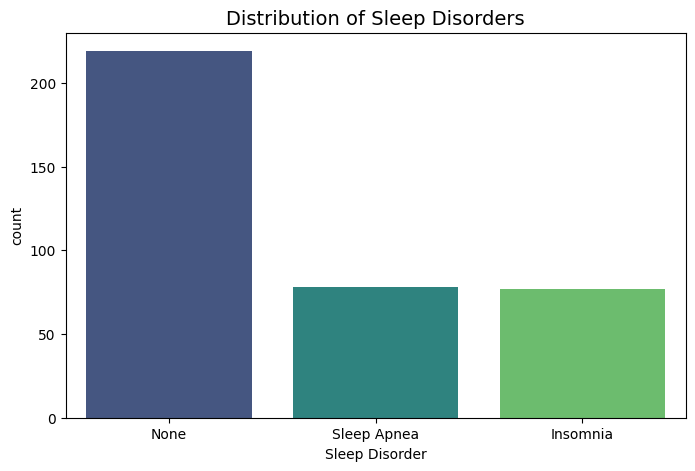

In [ ]:
# Class Balance
plt.figure(figsize=(8, 5))
sns.countplot(data=sleep, x='Sleep Disorder', palette='viridis')
plt.title('Distribution of Sleep Disorders', fontsize=14)
plt.savefig('target_distribution.png')

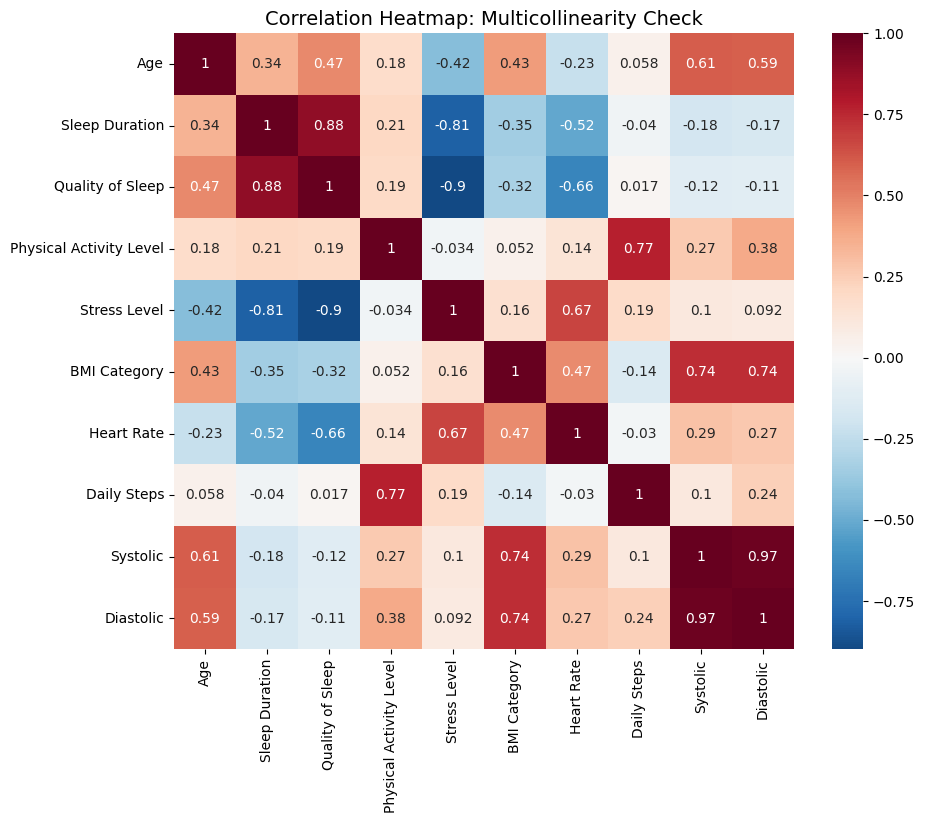

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = sleep.select_dtypes(include=[np.number]).drop(columns=['Person ID'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap: Multicollinearity Check', fontsize=14)
plt.savefig('correlation_heatmap.png')

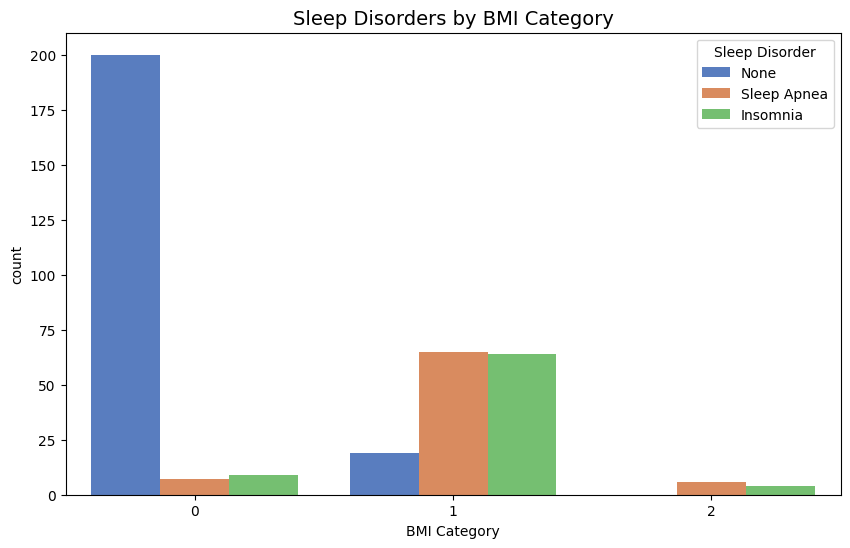

In [ ]:
# BMI Category vs. Sleep Disorder
plt.figure(figsize=(10, 6))
sns.countplot(data=sleep, x='BMI Category', hue='Sleep Disorder', palette='muted')
plt.title('Sleep Disorders by BMI Category', fontsize=14)
plt.savefig('bmi_analysis.png')

/tmp/ipykernel_5203/1999839309.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sleep, x='Stress Level', y='Quality of Sleep', palette='coolwarm')


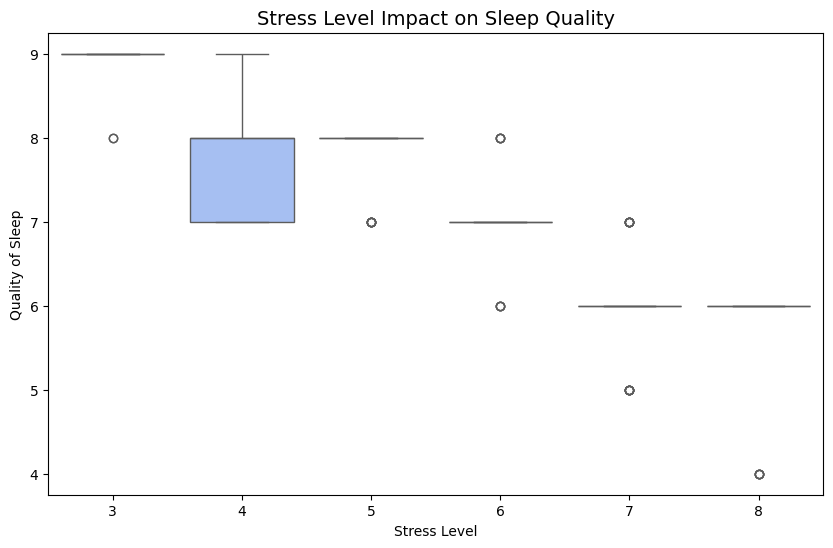

In [ ]:
# Stress vs. Quality
plt.figure(figsize=(10, 6))
sns.boxplot(data=sleep, x='Stress Level', y='Quality of Sleep', palette='coolwarm')
plt.title('Stress Level Impact on Sleep Quality', fontsize=14)
plt.savefig('stress_quality_boxplot.png')

## Prediction Models

### Create Train/Test Split

In [ ]:
# Define Features (x) and Target (y)
# Drop Sleep Disorder because it is the target, and Person ID because its an index
x = sleep.drop(['Sleep Disorder', 'Person ID'], axis=1)
y = sleep['Sleep Disorder']

# Establish the Train/Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

# Scale the Features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# print to see sizes
print(x_train.shape)
print(x_test.shape)

(299, 21)
(75, 21)


### Method 1: K-Nearest Neighbors

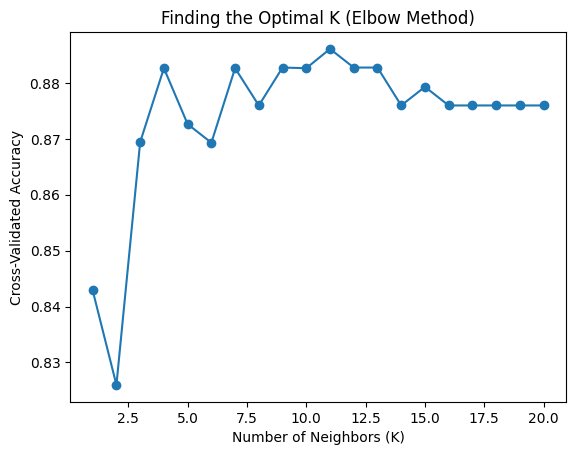

In [ ]:
# Finding the best K (between 1 and 20)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state = 42)
k_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x_train_scaled, y_train, cv=cv, scoring='accuracy')
    k_scores.append(scores.mean())

# Plotting the selection of K
plt.plot(range(1, 21), k_scores, marker='o')
plt.title('Finding the Optimal K (Elbow Method)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validated Accuracy')
plt.show()

In [ ]:
# Final Model using k = 11
knn_model = KNeighborsClassifier(n_neighbors=11)
knn_model.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=11)

In [ ]:
# Evaluation
y_pred = knn_model.predict(x_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Insomnia       0.74      0.93      0.82        15
        None       0.95      0.95      0.95        44
 Sleep Apnea       1.00      0.75      0.86        16

    accuracy                           0.91        75
   macro avg       0.90      0.88      0.88        75
weighted avg       0.92      0.91      0.91        75



<Figure size 800x600 with 0 Axes>

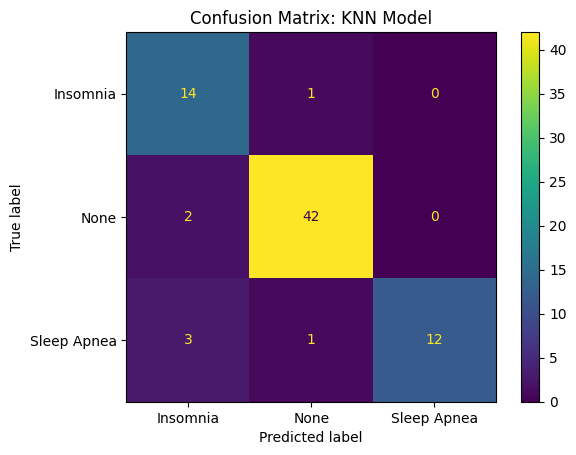

In [ ]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    knn_model, x_test_scaled, y_test,
    display_labels=['Insomnia', 'None', 'Sleep Apnea'])
plt.title('Confusion Matrix: KNN Model')
plt.show()

In [ ]:
# AUC-ROC Score
y_probs = knn_model.predict_proba(x_test_scaled)

# get the multi-class AUC-ROC using one-vs-rest
auc_roc = roc_auc_score(y_test, y_probs, multi_class='ovr', average='weighted')
print(f"KNN AUC-ROC: {auc_roc:.4f}")

KNN AUC-ROC: 0.9719


### Method 2: Logistic Regression

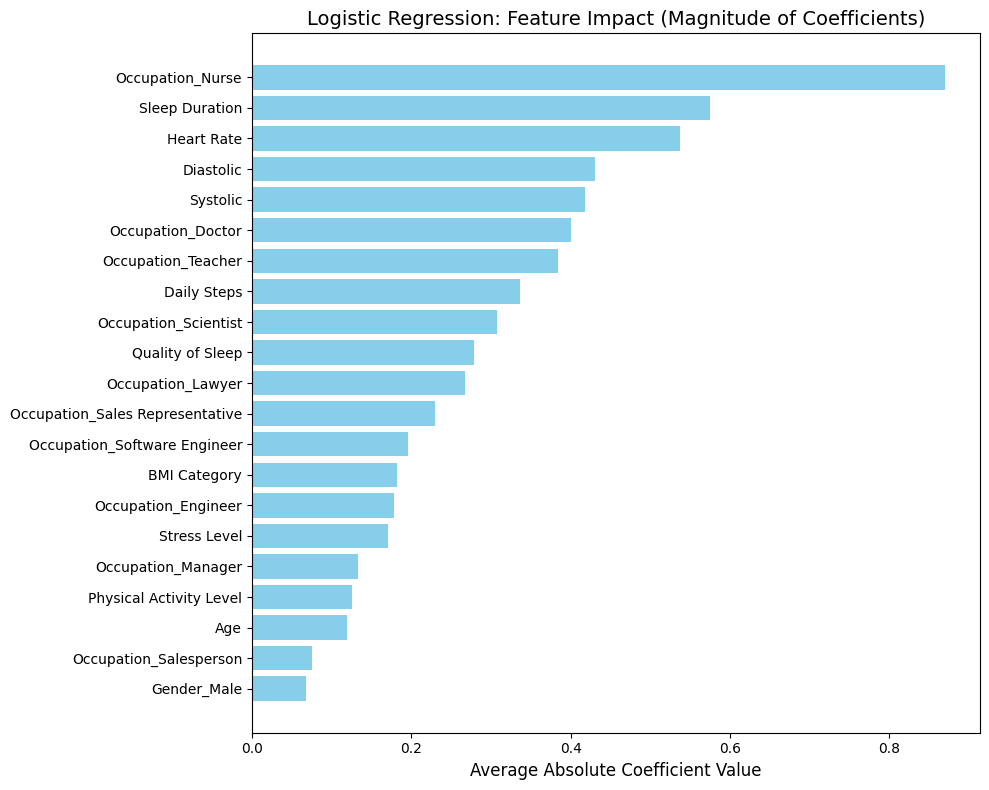

In [ ]:
# For logisitic regression we want to choose the best features for the model to get rid of noise
log_reg_base = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
log_reg_base.fit(x_train_scaled, y_train)

# For multinomial, we take the mean of absolute coefficients across the 3 classes to get a general 'importance'
feature_importance = np.mean(np.abs(log_reg_base.coef_), axis=0)
feature_names = x.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# plot the features
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.title('Logistic Regression: Feature Impact (Magnitude of Coefficients)', fontsize=14)
plt.xlabel('Average Absolute Coefficient Value', fontsize=12)
plt.tight_layout()

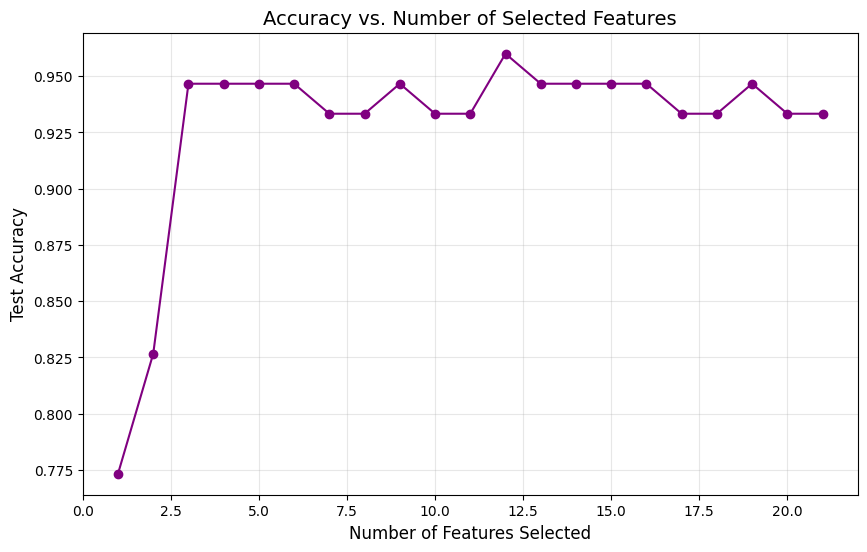

In [ ]:
# Recursive Feature Elimination (RFE), test the features to see which count gives the best accuracy
acc_scores = []
feature_counts = range(1, len(feature_names) + 1)

for n in feature_counts:
    rfe = RFE(estimator=log_reg_base, n_features_to_select=n)
    rfe.fit(x_train_scaled, y_train)
    x_train_rfe = rfe.transform(x_train_scaled)
    x_test_rfe = rfe.transform(x_test_scaled)

    lr_temp = LogisticRegression(max_iter=5000)
    lr_temp.fit(x_train_rfe, y_train)
    acc_scores.append(lr_temp.score(x_test_rfe, y_test))

# plot the # of features and accuracy
plt.figure(figsize=(10, 6))
plt.plot(feature_counts, acc_scores, marker='o', color='purple')
plt.title('Accuracy vs. Number of Selected Features', fontsize=14)
plt.xlabel('Number of Features Selected', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)

In [ ]:
# now we create the final model with the best features
# based on above we should choose 12 features
optimal_n = feature_counts[np.argmax(acc_scores)]
rfe_final = RFE(estimator=log_reg_base, n_features_to_select=optimal_n)
rfe_final.fit(x_train_scaled, y_train)

x_train_final = rfe_final.transform(x_train_scaled)
x_test_final = rfe_final.transform(x_test_scaled)

lr_model = LogisticRegression(max_iter=5000)
lr_model.fit(x_train_final, y_train)

print(f"Optimal Number of Features: {optimal_n}")
print(f"Top Features: {list(x.columns[rfe_final.support_])}")
print(f"Accuracy with {optimal_n} features: {max(acc_scores):.4f}")

Optimal Number of Features: 12
Top Features: ['Sleep Duration', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Lawyer', 'Occupation_Nurse', 'Occupation_Sales Representative', 'Occupation_Scientist', 'Occupation_Teacher']
Accuracy with 12 features: 0.9600


Logistic Regression Final Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.89      1.00      0.94        16

    accuracy                           0.96        75
   macro avg       0.94      0.95      0.94        75
weighted avg       0.96      0.96      0.96        75



Text(0.5, 1.0, 'Confusion Matrix: Logistic Regression (12 Features)')

<Figure size 800x600 with 0 Axes>

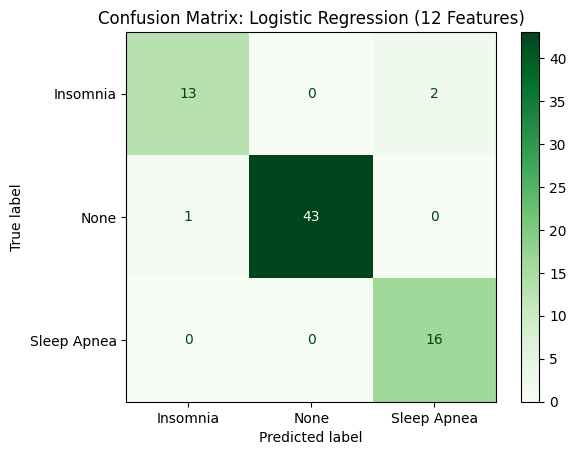

In [ ]:
# create classification report and confusion matrix to get an idea of false negs and positives
# Classification Report
report = classification_report(y_test, lr_model.predict(x_test_final))
print("Logistic Regression Final Classification Report:")
print(report)

# Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    lr_model, x_test_final, y_test, cmap='Greens',
    display_labels=lr_model.classes_)
plt.title(f'Confusion Matrix: Logistic Regression ({optimal_n} Features)')

In [ ]:
# Final AUC for comparison
y_probs_final = lr_model.predict_proba(x_test_final)
final_auc_rfe = roc_auc_score(y_test, y_probs_final, multi_class='ovr', average='weighted')

print(f"Final Weighted AUC-ROC: {final_auc_rfe:.4f}")

Final Weighted AUC-ROC: 0.9920


### Method 3: Random Forest

In [ ]:
# For Random Forest we are going to tune the max depth and amount of estimators
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10, None]
}

rf_base = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf_base, param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(x_train_scaled, y_train)

best_params = grid_rf.best_params_
print(f"Best RF Parameters: {best_params}")

Best RF Parameters: {'max_depth': 7, 'n_estimators': 50}


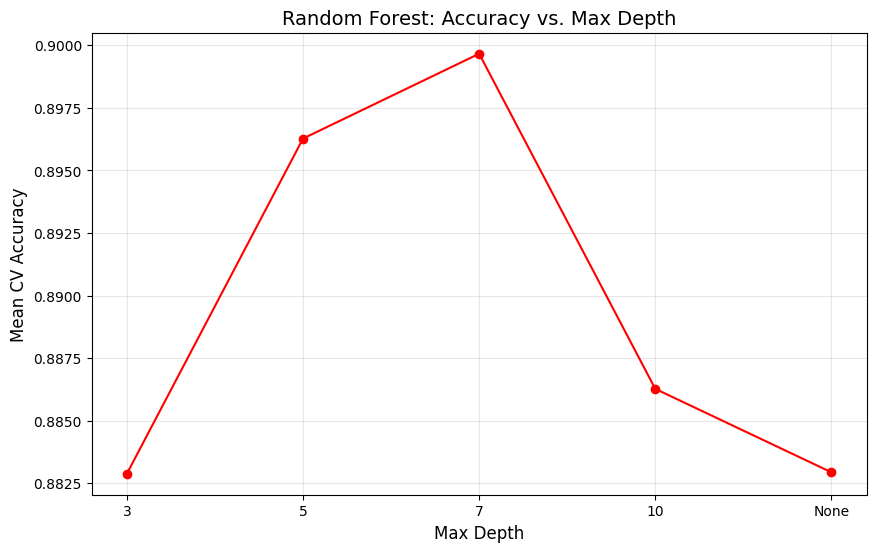

In [ ]:
# Visualizing Accuracy (Accuracy vs Max Depth)
results_rf = pd.DataFrame(grid_rf.cv_results_)
# Filter for n_estimators=50 to see impact of depth
depth_tuning = results_rf[results_rf['param_n_estimators'] == 50]

plt.figure(figsize=(10, 6))
plt.plot(depth_tuning['param_max_depth'].fillna('None').astype(str), depth_tuning['mean_test_score'], marker='o', color='red')
plt.title('Random Forest: Accuracy vs. Max Depth', fontsize=14)
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('Mean CV Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)

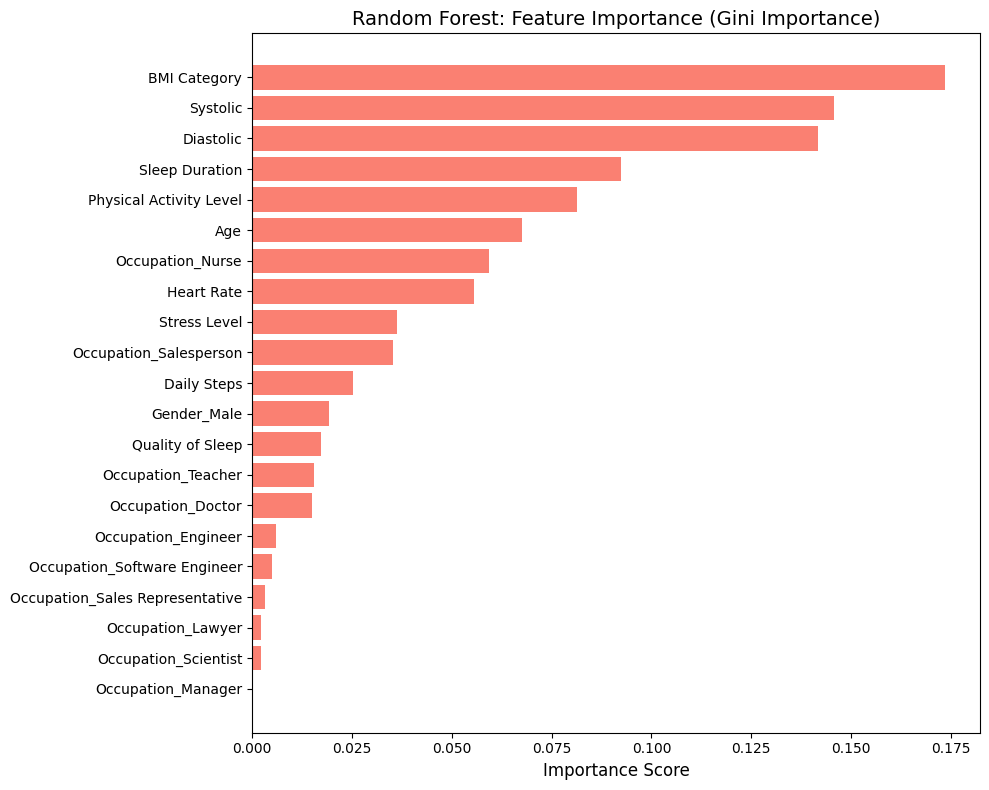

In [ ]:
# Now do feature importance
rf_best = grid_rf.best_estimator_
importances = rf_best.feature_importances_
feature_names = x.columns
rf_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='salmon')
plt.title('Random Forest: Feature Importance (Gini Importance)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()

In [ ]:
# make the optimzed model based on feature importance
acc_scores_rf = []
feature_counts = range(1, len(feature_names) + 1)

for n in feature_counts:
    rfe_rf = RFE(estimator=rf_best, n_features_to_select=n)
    rfe_rf.fit(x_train_scaled, y_train)
    x_train_rfe = rfe_rf.transform(x_train_scaled)
    x_test_rfe = rfe_rf.transform(x_test_scaled)

    rf_temp = RandomForestClassifier(**best_params, random_state=42)
    rf_temp.fit(x_train_rfe, y_train)
    acc_scores_rf.append(rf_temp.score(x_test_rfe, y_test))

optimal_n_rf = feature_counts[np.argmax(acc_scores_rf)]
rfe_rf_final = RFE(estimator=rf_best, n_features_to_select=optimal_n_rf)
rfe_rf_final.fit(x_train_scaled, y_train)

x_train_rf_final = rfe_rf_final.transform(x_train_scaled)
x_test_rf_final = rfe_rf_final.transform(x_test_scaled)

rf_model = RandomForestClassifier(**best_params, random_state=42)
rf_model.fit(x_train_rf_final, y_train)

print(f"Optimal Number of Features (RF): {optimal_n_rf}")
print(f"Top RF Features: {list(x.columns[rfe_rf_final.support_])}")
print(f"RF Test Accuracy: {rf_model.score(x_test_rf_final, y_test):.4f}")

Optimal Number of Features (RF): 4
Top RF Features: ['Sleep Duration', 'BMI Category', 'Systolic', 'Diastolic']
RF Test Accuracy: 0.9733


In [ ]:
#report for random forests
report = classification_report(y_test, rf_model.predict(x_test_rf_final))
print("Random Forests Final Classification Report:")
print(report)

Random Forests Final Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.93      0.93      0.93        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.94      0.94      0.94        16

    accuracy                           0.97        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.97      0.97      0.97        75



Text(0.5, 1.0, 'Confusion Matrix: Random Forest (4 Features)')

<Figure size 800x600 with 0 Axes>

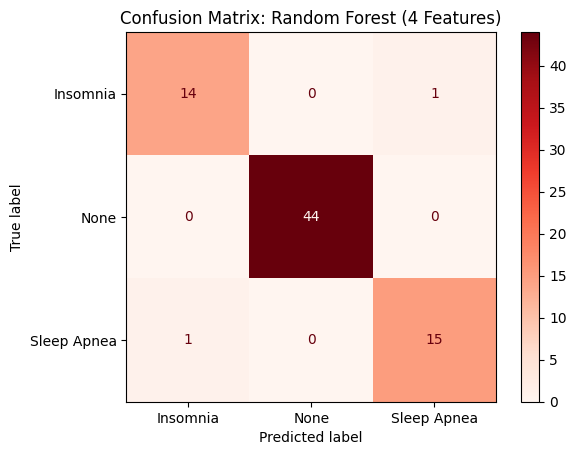

In [ ]:
# now we evaluate the model
# Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, x_test_rf_final, y_test, cmap='Reds', display_labels=rf_model.classes_)
plt.title(f'Confusion Matrix: Random Forest ({optimal_n_rf} Features)')

In [ ]:
# ROC Curves
y_probs_rf = rf_model.predict_proba(x_test_rf_final)
classes = rf_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

print(f"RF Weighted AUC-ROC: {roc_auc_score(y_test, y_probs_rf, multi_class='ovr', average='weighted'):.4f}")

RF Weighted AUC-ROC: 0.9978


## Comparison of all Methods

In [ ]:
# Helper to grab metrics from the hold-out test sets
test_comparison = {
    'Method': ['KNN', 'Logistic Regression', 'Random Forest'],
    'Features': ['All (21)', f'{optimal_n}', f'{optimal_n_rf}'],
    'Test Accuracy': [
        knn_model.score(x_test_scaled, y_test),
        lr_model.score(x_test_final, y_test),
        rf_model.score(x_test_rf_final, y_test)
    ],
    'Test F1 (Weighted)': [
        f1_score(y_test, knn_model.predict(x_test_scaled), average='weighted'),
        f1_score(y_test, lr_model.predict(x_test_final), average='weighted'),
        f1_score(y_test, rf_model.predict(x_test_rf_final), average='weighted')
    ],
    'Test AUC-ROC': [
        roc_auc_score(y_test, knn_model.predict_proba(x_test_scaled), multi_class='ovr', average='weighted'),
        roc_auc_score(y_test, lr_model.predict_proba(x_test_final), multi_class='ovr', average='weighted'),
        roc_auc_score(y_test, rf_model.predict_proba(x_test_rf_final), multi_class='ovr', average='weighted')
    ]
}

df_test_compare = pd.DataFrame(test_comparison).round(4)
print("PREDICTION METHOD MODELS COMPARISON")
display(df_test_compare)

PREDICTION METHOD MODELS COMPARISON


,Method,Features,Test Accuracy,Test F1 (Weighted),Test AUC-ROC
0,KNN,All (21),0.9067,0.9076,0.9719
1,Logistic Regression,12,0.9600,0.9600,0.9920
2,Random Forest,4,0.9733,0.9733,0.9978


## Inference Model

In [ ]:
path = '/content/drive/MyDrive/Statistical Learning/final project/sleep_health_and_lifestyle_dataset.csv'
df = pd.read_csv(path)

# Fill NAs in the Sleep Disorder Column
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# Split Blood Pressure into Systolic and Diastolic
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df = df.drop('Blood Pressure', axis=1)
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [ ]:
df['Sleep Disorder'].value_counts()

,count
Sleep Disorder,
None,219
Sleep Apnea,78
Insomnia,77


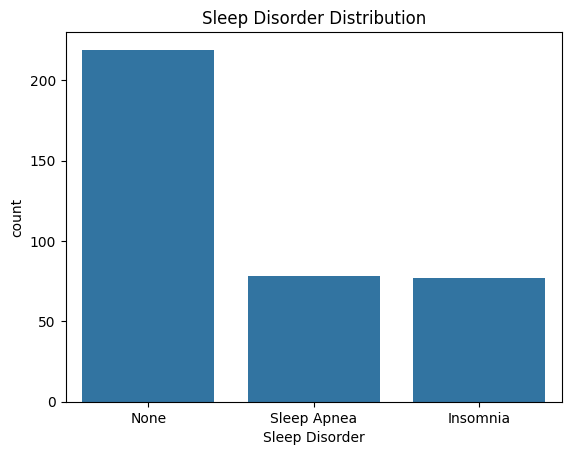

In [ ]:
sns.countplot(data=df, x='Sleep Disorder')

plt.title('Sleep Disorder Distribution')
plt.show()

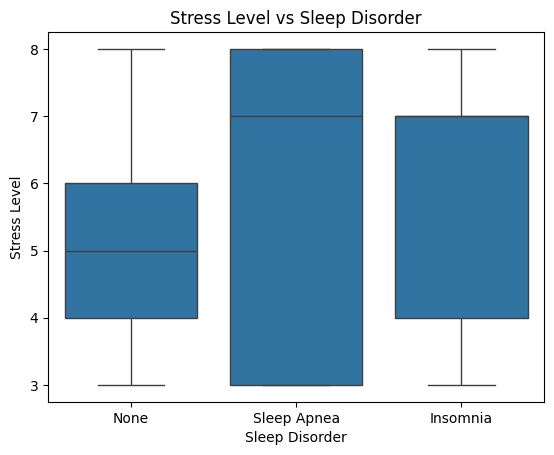

In [ ]:
sns.boxplot(data=df, x='Sleep Disorder', y='Stress Level')

plt.title('Stress Level vs Sleep Disorder')
plt.show()

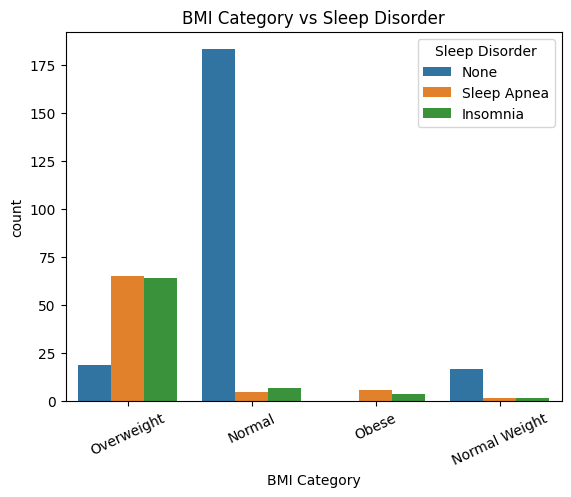

In [ ]:
sns.countplot(data=df, x='BMI Category', hue='Sleep Disorder')

plt.title('BMI Category vs Sleep Disorder')
plt.xticks(rotation=25)

plt.show()

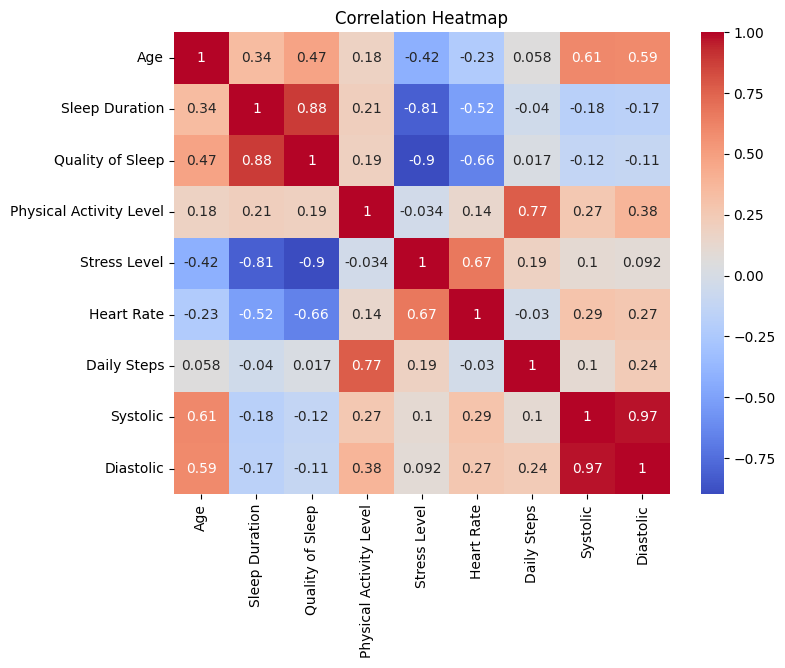

In [ ]:
num_cols = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Systolic',
    'Diastolic'
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
df_model = df.copy()

df_model = pd.get_dummies(df_model, columns=['Gender','BMI Category','Occupation'], drop_first=True)

df_model.head()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,1,27,6.1,6,42,6,77,4200,None,126,...,False,False,False,False,False,False,False,False,True,False
1,2,28,6.2,6,60,8,75,10000,None,125,...,True,False,False,False,False,False,False,False,False,False
2,3,28,6.2,6,60,8,75,10000,None,125,...,True,False,False,False,False,False,False,False,False,False
3,4,28,5.9,4,30,8,85,3000,Sleep Apnea,140,...,False,False,False,False,False,True,False,False,False,False
4,5,28,5.9,4,30,8,85,3000,Sleep Apnea,140,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
df_model['Sleep Disorder'] = df_model['Sleep Disorder'].astype('category')

y = df_model['Sleep Disorder'].cat.codes

X = df_model.drop(columns=['Sleep Disorder','Person ID'])

X = sm.add_constant(X)

In [ ]:
X = X.astype(int)

model = sm.MNLogit(y, X)

result = model.fit()

result.summary()

         Current function value: 0.251639
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:                      y   No. Observations:                  374
Model:                        MNLogit   Df Residuals:                      326
Method:                           MLE   Df Model:                           46
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                  0.7394
Time:                        15:31:34   Log-Likelihood:                -94.113
converged:                      False   LL-Null:                       -361.17
Covariance Type:            nonrobust   LLR p-value:                 2.459e-84
===================================================================================================
                            y=1       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                             322.0468    181.989      1.770      0.077     -34.645     678.739
Age                                -0.0304      0.378     -0.080      0.936      -0.772       0.711
Sleep Duration                     -0.9958      3.976     -0.250      0.802      -8.789       6.797
Quality of Sleep                   -0.3842      3.855     -0.100      0.921      -7.939       7.171
Physical Activity Level             0.0174      0.078      0.223      0.824      -0.135       0.170
Stress Level                       -4.4133      4.303     -1.026      0.305     -12.847       4.020
Heart Rate                         -0.2500      0.956     -0.261      0.794      -2.124       1.624
Daily Steps                         0.0057      0.004      1.566      0.117      -0.001       0.013
Systolic                           -2.2187      2.733     -0.812      0.417      -7.576       3.139
Diastolic                          -0.7809      3.069     -0.254      0.799      -6.795       5.234
Gender_Male                         3.6275      4.910      0.739      0.460      -5.996      13.251
BMI Category_Normal Weight         19.8480     11.724      1.693      0.090      -3.130      42.826
BMI Category_Obese                 10.1149   8.02e+06   1.26e-06      1.000   -1.57e+07    1.57e+07
BMI Category_Overweight            22.7154     13.650      1.664      0.096      -4.039      49.470
Occupation_Doctor                  50.9211     27.809      1.831      0.067      -3.584     105.426
Occupation_Engineer                34.9263     20.373      1.714      0.086      -5.003      74.856
Occupation_Lawyer                  36.0287     20.138      1.789      0.074      -3.440      75.497
Occupation_Manager                 23.2369     53.834      0.432      0.666     -82.276     128.750
Occupation_Nurse                   46.1596     24.959      1.849      0.064      -2.760      95.079
Occupation_Sales Representative    71.6298   1.78e+07   4.04e-06      1.000   -3.48e+07    3.48e+07
Occupation_Salesperson             27.4240     19.646      1.396      0.163     -11.081      65.929
Occupation_Scientist               73.4204   2.07e+06   3.54e-05      1.000   -4.06e+06    4.06e+06
Occupation_Software Engineer       58.9568   1605.077      0.037      0.971   -3086.937    3204.851
Occupation_Teacher                 31.6495     21.338      1.483      0.138     -10.173      73.472
---------------------------------------------------------------------------------------------------
                            y=2       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -0.9427    113.226     -0.008      0.993    -222.861     220.976
Age                                -0.3612      0.467     -0.773      0.439      -1.277       0.554
Sleep Duration                      2.102

In [ ]:
features = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Systolic',
    'Diastolic'
]

X_clean = df_model[features]

X_clean = sm.add_constant(X_clean)

model_clean = sm.MNLogit(y, X_clean)

result_clean = model_clean.fit()

result_clean.summary()

Optimization terminated successfully.
         Current function value: 0.352539
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:                      y   No. Observations:                  374
Model:                        MNLogit   Df Residuals:                      354
Method:                           MLE   Df Model:                           18
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                  0.6349
Time:                        15:31:34   Log-Likelihood:                -131.85
converged:                       True   LL-Null:                       -361.17
Covariance Type:            nonrobust   LLR p-value:                 5.027e-86
===========================================================================================
                    y=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -4.8746     14.325     -0.340      0.734     -32.951      23.201
Age                        -0.2518      0.052     -4.802      0.000      -0.355      -0.149
Sleep Duration              1.3640      0.957      1.425      0.154      -0.511       3.239
Quality of Sleep            2.4999      0.679      3.679      0.000       1.168       3.832
Physical Activity Level    -0.0512      0.034     -1.507      0.132      -0.118       0.015
Stress Level                0.6585      0.418      1.576      0.115      -0.160       1.477
Heart Rate                  0.1604      0.126      1.270      0.204      -0.087       0.408
Daily Steps                 0.0007      0.001      1.317      0.188      -0.000       0.002
Systolic                   -0.5653      0.256     -2.210      0.027      -1.067      -0.064
Diastolic                   0.5421      0.315      1.722      0.085      -0.075       1.159
-------------------------------------------------------------------------------------------
                    y=2       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     -78.4309     19.616     -3.998      0.000    -116.877     -39.985
Age                        -0.1429      0.071     -2.018      0.044      -0.282      -0.004
Sleep Duration              3.8543      1.281      3.008      0.003       1.343       6.366
Quality of Sleep            0.6234      0.867      0.719      0.472      -1.076       2.323
Physical Activity Level    -0.1327      0.046     -2.863      0.004      -0.224      -0.042
Stress Level                0.1202      0.581      0.207      0.836      -1.018       1.258
Heart Rate                  0.6334      0.150      4.226      0.000       0.340       0.927
Daily Steps                 0.0017      0.001      3.062      0.002       0.001       0.003
Systolic                   -0.8488      0.255     -3.334      0.001      -1.348      -0.350
Diastolic                   1.3254      0.328      4.044      0.000       0.683       1.968
===========================================================================================
"""

In [ ]:
params = result_clean.params

odds_ratios = np.exp(params)

odds_ratios

,0,1
const,0.007638,8.667069e-35
Age,0.777393,8.668499e-01
Sleep Duration,3.911628,4.719645e+01
Quality of Sleep,12.181837,1.865210e+00
Physical Activity Level,0.950064,8.757378e-01
Stress Level,1.931877,1.127670e+00
Heart Rate,1.173989,1.884045e+00
Daily Steps,1.000665,1.001733e+00
Systolic,0.568198,4.279173e-01
Diastolic,1.719639,3.763507e+00


In [ ]:
pvals = result_clean.pvalues

sig = pvals[pvals < 0.05]

sig

,0,1
const,NaN,0.000064
Age,0.000002,0.043631
Sleep Duration,NaN,0.002628
Quality of Sleep,0.000234,NaN
Physical Activity Level,NaN,0.004195
Stress Level,NaN,NaN
Heart Rate,NaN,0.000024
Daily Steps,NaN,0.002199
Systolic,0.027134,0.000857
Diastolic,NaN,0.000052


In [ ]:
summary_table = pd.concat(
    [
        result_clean.params,
        odds_ratios,
        result_clean.pvalues
    ],
    axis=1
)

summary_table.columns = ['coef_0','coef_1','odds_0','odds_1','pval_0','pval_1']

summary_table.sort_values('pval_1')

,coef_0,coef_1,odds_0,odds_1,pval_0,pval_1
Heart Rate,0.160408,0.633421,1.173989,1.884045e+00,0.204124,0.000024
Diastolic,0.542114,1.325351,1.719639,3.763507e+00,0.085014,0.000052
const,-4.874642,-78.430948,0.007638,8.667069e-35,0.733634,0.000064
Systolic,-0.565286,-0.848825,0.568198,4.279173e-01,0.027134,0.000857
Daily Steps,0.000665,0.001731,1.000665,1.001733e+00,0.187705,0.002199
Sleep Duration,1.363954,3.854319,3.911628,4.719645e+01,0.154013,0.002628
Physical Activity Level,-0.051226,-0.132689,0.950064,8.757378e-01,0.131896,0.004195
Age,-0.251810,-0.142889,0.777393,8.668499e-01,0.000002,0.043631
Quality of Sleep,2.499946,0.623374,12.181837,1.865210e+00,0.000234,0.472272
Stress Level,0.658492,0.120154,1.931877,1.127670e+00,0.114989,0.836055


In [ ]:
top_predictors = summary_table.sort_values('pval_1').head(5)

top_predictors

,coef_0,coef_1,odds_0,odds_1,pval_0,pval_1
Heart Rate,0.160408,0.633421,1.173989,1.884045e+00,0.204124,0.000024
Diastolic,0.542114,1.325351,1.719639,3.763507e+00,0.085014,0.000052
const,-4.874642,-78.430948,0.007638,8.667069e-35,0.733634,0.000064
Systolic,-0.565286,-0.848825,0.568198,4.279173e-01,0.027134,0.000857
Daily Steps,0.000665,0.001731,1.000665,1.001733e+00,0.187705,0.002199


## Systemic Method Comparison

In [ ]:
from sklearn.model_selection import cross_validate

#get all models for compairson
knn_model_comp = knn_model
lr_model_comp = lr_model
rf_model_comp = rf_model

# define the metrics for comparison
scoring_metrics = ['accuracy', 'f1_weighted', 'roc_auc_ovr_weighted']

# Perform Cross-Validation for each Method
knn_cv_results = cross_validate(
    knn_model_comp,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring_metrics
)

lr_cv_results = cross_validate(
    lr_model_comp,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring_metrics
)

rf_cv_results = cross_validate(
    rf_model_comp,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring_metrics
)

In [ ]:
# Get all information into a comparison chart
comparison_data = {
    'Method': ['KNN', 'Logistic Regression', 'Random Forest'],
    'Optimal Config': [f'All Features (21)', f'12 Features', f'4 Features'],
    'CV Accuracy (Mean)': [
        knn_cv_results['test_accuracy'].mean(),
        lr_cv_results['test_accuracy'].mean(),
        rf_cv_results['test_accuracy'].mean()
    ],
    'CV Accuracy (Std)': [
        knn_cv_results['test_accuracy'].std(),
        lr_cv_results['test_accuracy'].std(),
        rf_cv_results['test_accuracy'].std()
    ],
    'CV F1-Score (Weighted)': [
        knn_cv_results['test_f1_weighted'].mean(),
        lr_cv_results['test_f1_weighted'].mean(),
        rf_cv_results['test_f1_weighted'].mean()
    ],
    'CV AUC-ROC (Weighted)': [
        knn_cv_results['test_roc_auc_ovr_weighted'].mean(),
        lr_cv_results['test_roc_auc_ovr_weighted'].mean(),
        rf_cv_results['test_roc_auc_ovr_weighted'].mean()
    ]
}

# create the df and round
df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.round(4)

# Display the final systematic comparison table
print("SYSTEMATIC METHOD COMPARISON")
display(df_comparison)

SYSTEMATIC METHOD COMPARISON


,Method,Optimal Config,CV Accuracy (Mean),CV Accuracy (Std),CV F1-Score (Weighted),CV AUC-ROC (Weighted)
0,KNN,All Features (21),0.8861,0.0316,0.8855,0.9042
1,Logistic Regression,12 Features,0.8929,0.0363,0.8920,0.9002
2,Random Forest,4 Features,0.8863,0.0399,0.8855,0.9051
